# Team 9 ML Training and Testing


*   Create a test set and a training set using the original dataset
*   Follow the steps that we use in our hands-ons to prepare the data and pipeline for training at least 3 ML models. Use any strategy that you see fit. Use N-fold cross-validation to evaluate the performance of each model.
*   Graphs for initial data exploration
*   Description of test data and test strategy you use
* Select the best performance metrics to evaluate your models for testing and explain why you choose this model
* Test your best ML model using the test set. Include a confusion matrix to show the performance of your best class ML model.





# Create a test set and a training set using the original dataset

In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt


In [2]:
# Dataset
diabetes_df = pd.read_csv('diabetes_dataset.csv')


kept_stages = ["Type 2", "Pre-Diabetes", "No Diabetes"]
diabetes_df = diabetes_df[diabetes_df["diabetes_stage"].isin(kept_stages)].copy()
diabetes_df = diabetes_df.reset_index(drop=True)

print("Filtered dataset shape:", diabetes_df.shape)
print(diabetes_df["diabetes_stage"].value_counts())

diabetes_df.head()

Filtered dataset shape: (99600, 31)
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Name: count, dtype: int64


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(diabetes_df, diabetes_df["diabetes_stage"]):
    strat_train_set = diabetes_df.iloc[train_index]
    strat_test_set = diabetes_df.iloc[test_index]

# Prepare the Data and Pipeline for Training at least 3 ML Models


*   Use N-fold cross-validation to evaluate the performance of each model




## Data Cleaning and Pipeline

In [20]:
diabetes_df.isnull().sum().sum()

0

In [21]:
diabetes_df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [5]:
# Drop target and diagnossed diatebes columns from features
#Diagnose diabetes columns can isntantly tell the ML models that if diagnosed diabetes is 1, then it is type 2 so we drop that
target_col = "diabetes_stage"
cols_to_drop = [target_col, "diagnosed_diabetes"]

X_train = strat_train_set.drop(columns=cols_to_drop, errors="ignore")
y_train = strat_train_set[target_col]
X_test = strat_test_set.drop(columns=cols_to_drop, errors="ignore")
y_test = strat_test_set[target_col]

# Split columns into numeric and categorical groups
num_attribs = X_train.select_dtypes(include="number").columns.tolist()
cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Pipeline for numeric columns
num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline for categorical columns
cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Combine pipelines
full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

print("Target class distribution in training set:")
print(y_train.value_counts(normalize=True).round(4))
print("Numeric columns:", len(num_attribs))
print("Categorical columns:", len(cat_attribs))


Target class distribution in training set:
diabetes_stage
Type 2          0.6001
Pre-Diabetes    0.3197
No Diabetes     0.0801
Name: proportion, dtype: float64
Numeric columns: 23
Categorical columns: 6


## First Model

In [6]:
log_reg_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42,
            class_weight="balanced",
            solver="lbfgs",
        ),
    ),
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'alcohol_consumption_per_week',
                                                   'physical_activity_minutes_per_week',
                                                   'diet_score',
                                                   'sleep_hours_per_day',
                                                   'screen_time_hours_per_day',
                                                   'family_history_diabetes',
                                                   'hypertension_history',
                                                   'ca...
                                                   'diabetes_risk_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'ethnicity',
                                                   'education_level',
                                                   'income_level',
                                                   'employment_status',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [7]:
# Gives warnings for using cross_validate + recall and precision unless it specifies a type of it to use like weighted recall
# Weighted appears to accomodate for imbalance classes scoring
# Crashes if using roc_auc without ovo or ovr
scoring = ["f1_macro", "accuracy", "recall_weighted", "precision_weighted", "roc_auc_ovo"]
scores = cross_validate(
    log_reg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

print(scores.keys())
def display_scores(scores):
    print("Scores:")

    
    print("F1 Macro Mean: ", scores['test_f1_macro'].mean())
    # print("F1 Macro Scores: ", scores['test_f1_macro'])
    # print("F1 Standard deviation:", scores['test_f1_macro'].std())

    
    print("Accuracy Mean: ", scores['test_accuracy'].mean())
    # print("Accuracy Scores:", scores['test_accuracy'])
    # print("Accuracy deviation:", scores['test_accuracy'].std())

    
    print("Recall Weighted Mean: ", scores['test_recall_weighted'].mean())
    # print("Recall Weighted Scores: ", scores['test_recall_weighted'])
    # print("Recall Weighted deviation:", scores['test_recall_weighted'].std())
    
    
    print("Precision Weighted Mean: ", scores['test_precision_weighted'].mean())
    # print("Precision Weighted Scores: ", scores['test_precision_weighted'])
    # print("Precision Weighted deviation:", scores['test_precision_weighted'].std())

    
    print("ROC AUC OVR Mean: ", scores['test_roc_auc_ovo'].mean())
    # print("ROC AUC OVR Scores: ", scores['test_roc_auc_ovo'])
    # print("ROC AUC OVR deviation:", scores['test_roc_auc_ovo'].std())
    
display_scores(scores)

dict_keys(['fit_time', 'score_time', 'test_f1_macro', 'test_accuracy', 'test_recall_weighted', 'test_precision_weighted', 'test_roc_auc_ovo'])
Scores:
F1 Macro Mean:  0.833755039163778
Accuracy Mean:  0.8672063253012048
Recall Weighted Mean:  0.8672063253012048
Precision Weighted Mean:  0.8805148857592041
ROC AUC OVR Mean:  0.9614617496323392


## Second Model

In [8]:
knn_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    ("model", KNeighborsClassifier(n_neighbors=15)),
])


knn_scores = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

display_scores(knn_scores)

Scores:
F1 Macro Mean:  0.7178847368962141
Accuracy Mean:  0.7883408634538152
Recall Weighted Mean:  0.7883408634538152
Precision Weighted Mean:  0.7911140373358522
ROC AUC OVR Mean:  0.8940888907716872


## Third Model

In [14]:
rf_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            max_depth=50,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    ),
])


rf_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

display_scores(rf_scores)

Scores:
F1 Macro Mean:  0.9182418790573132
Accuracy Mean:  0.920168172690763
Recall Weighted Mean:  0.920168172690763
Precision Weighted Mean:  0.9327838669598346
ROC AUC OVR Mean:  0.9738849578638835


# Select the best performance metrics to evaluate your models for testing and explain why you choose this model

## Fine Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.3, 0.5],
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'model__max_depth': None, 'model__max_features': 0.3, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
Best CV score: 0.9190720485792321


In [16]:
rf_pipeline_tuned = Pipeline([
    ("preprocess", full_pipeline),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            max_depth=None,
            max_features=0.3,
            min_samples_leaf=4,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    ),
])


rf_scores_tuned = cross_validate(
    rf_pipeline_tuned,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

display_scores(rf_scores_tuned)

Scores:
F1 Macro Mean:  0.9190720485792321
Accuracy Mean:  0.9208584337349398
Recall Weighted Mean:  0.9208584337349398
Precision Weighted Mean:  0.9339791575290741
ROC AUC OVR Mean:  0.9765559050220777


# Test your best ML model using the test set. Include a confusion matrix to show the performance of your best class ML model.

Model: Random Forest
Accuracy: 0.9223393574297188
Recall: 0.9568660253729262
Precision: 0.8943689284404787
F1: 0.919571054849961
ROC AUC: 0.9770152596834345


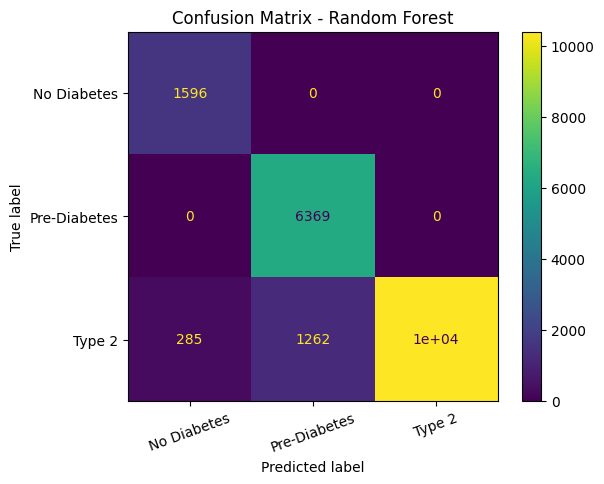

In [17]:
# Final testing with Random Forest on test set
rf_pipeline_tuned.fit(X_train, y_train)

y_pred = rf_pipeline_tuned.predict(X_test)
y_proba = rf_pipeline_tuned.predict_proba(X_test)

print("Model: Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))
print("Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba, multi_class="ovo"))


ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=20)
plt.title("Confusion Matrix - Random Forest")
plt.show()